STEP 1- INSTALLING THE DEPENDENCIES

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Energy_consumption.csv")

STEP 2 — Basic Inspection

In [4]:
df.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,2022-01-01 01:00:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,2022-01-01 02:00:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,2022-01-01 03:00:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,2022-01-01 04:00:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


In [6]:
df.describe()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.982026,45.395412,1500.052488,4.581000,15.132813,77.055873
std,2.836850,8.518905,288.418873,2.865598,8.745917,8.144112
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.645070,38.297722,1247.108548,2.000000,7.628385,71.544690
50%,24.751637,45.972116,1507.967426,5.000000,15.072296,76.943696
75%,27.418174,52.420066,1740.340165,7.000000,22.884064,82.921742
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


In [7]:
df.shape

(1000, 11)

In [8]:
df.columns

Index(['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
       'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday',
       'EnergyConsumption'],
      dtype='object')

STEP 3 — Check Missing Values

In [9]:
df.isnull().sum()

Timestamp            0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
DayOfWeek            0
Holiday              0
EnergyConsumption    0
dtype: int64

STEP 5 — Convert Timestamp

In [10]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          1000 non-null   datetime64[ns]
 1   Temperature        1000 non-null   float64       
 2   Humidity           1000 non-null   float64       
 3   SquareFootage      1000 non-null   float64       
 4   Occupancy          1000 non-null   int64         
 5   HVACUsage          1000 non-null   object        
 6   LightingUsage      1000 non-null   object        
 7   RenewableEnergy    1000 non-null   float64       
 8   DayOfWeek          1000 non-null   object        
 9   Holiday            1000 non-null   object        
 10  EnergyConsumption  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 86.1+ KB


Feature Engineering

STEP 6 — Extract Time Features

Extract Hour

In [12]:
df['hour'] = df['Timestamp'].dt.hour

Extract Day

In [13]:
df['day'] = df['Timestamp'].dt.day

Extract Month

In [14]:
df['month'] = df['Timestamp'].dt.month

Weekend Feature

In [15]:
df['is_weekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday']).astype(int)

STEP 7 — Univariate Analysis

Histograms

1. Temperature Distribution

I plotted a histogram for temperature to see the climatic spread. Because the dataset is synthetic, the distribution looks uniform (flat) across the 20°C to 30°C range rather than a bell curve. In a real-world scenario, a normal distribution would indicate seasonal or daily temperature cycles, whereas a flat distribution implies even representation across all temperature intervals

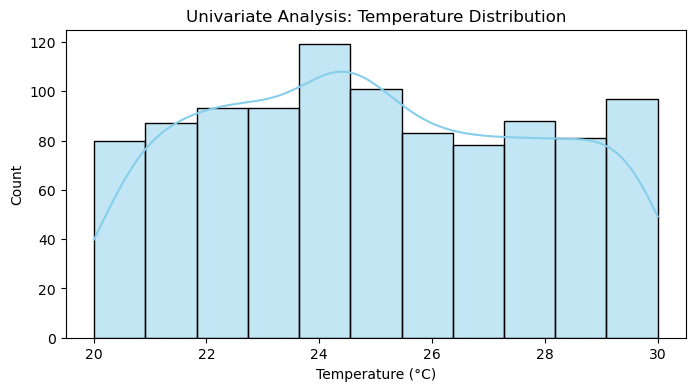

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Temperature'], kde=True, color='skyblue')
plt.title('Univariate Analysis: Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.show()

2. Humidity Distribution

Analyzing humidity individually tells us how often the building experiences dry vs. muggy conditions. Since humidity works closely with temperature to dictate HVAC load, knowing its spread helps verify that our data covers both high and low comfort-bound thresholds seamlessly.

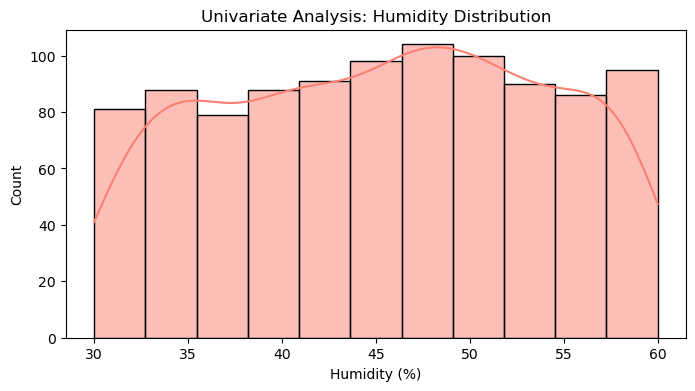

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Humidity'], kde=True, color='salmon')
plt.title('Univariate Analysis: Humidity Distribution')
plt.xlabel('Humidity (%)')
plt.ylabel('Count')
plt.show()

3. Square Footage Distribution

Square footage acts as a structural baseline feature. Checking its distribution ensures we don't have massive structural outliers (like a 50,000 sq ft warehouse mixed into 1,500 sq ft homes) which could heavily bias a linear regression model.

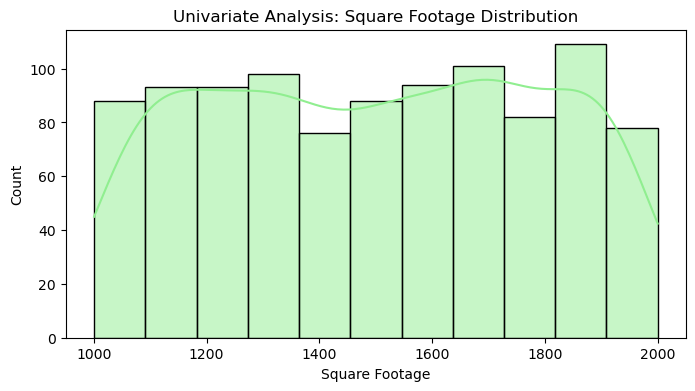

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(df['SquareFootage'], kde=True, color='lightgreen')
plt.title('Univariate Analysis: Square Footage Distribution')
plt.xlabel('Square Footage')
plt.ylabel('Count')
plt.show()

4. Occupancy Distribution

Occupancy is a discrete numerical variable representing human behavior. By looking at this plot, I can confirm that the data accounts for periods when the building is entirely empty (0 occupants) up to maximum capacity (9 occupants). This is vital because human density directly correlates with appliance usage and body heat load.

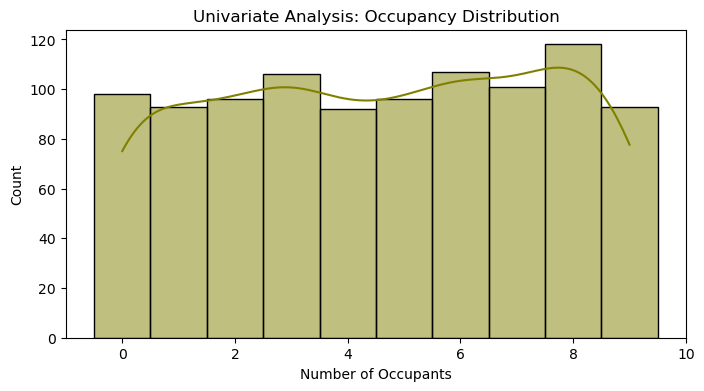

In [19]:
plt.figure(figsize=(8, 4))
# Using discrete=True because occupancy contains whole numbers (0 to 9 people)
sns.histplot(df['Occupancy'], kde=True, color='olive', discrete=True)
plt.title('Univariate Analysis: Occupancy Distribution')
plt.xlabel('Number of Occupants')
plt.ylabel('Count')
plt.show()

5. Renewable Energy Contribution

This plot checks how heavily reliance on renewable sources scales in our data. It shows a steady distribution up to 30%, which allows our upcoming models to learn whether high clean-energy generation offsets the grid energy demand linearly or dynamically.

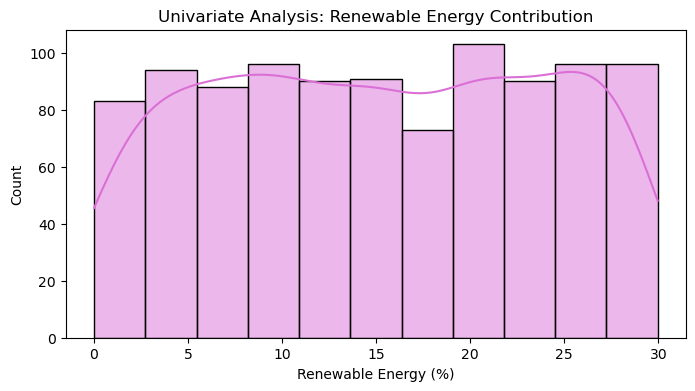

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df['RenewableEnergy'], kde=True, color='orchid')
plt.title('Univariate Analysis: Renewable Energy Contribution')
plt.xlabel('Renewable Energy (%)')
plt.ylabel('Count')
plt.show()

6. Target Variable: Energy Consumption

As a best practice, I isolated the target variable, Energy Consumption, to check for skewness. If the target distribution has a heavy right tail (highly skewed), standard linear algorithms struggle with predictions. If it displays a normal distribution or complex multimodal peaks, it indicates that a combination of features (like HVAC or Occupancy states) are heavily driving distinct consumption tiers.

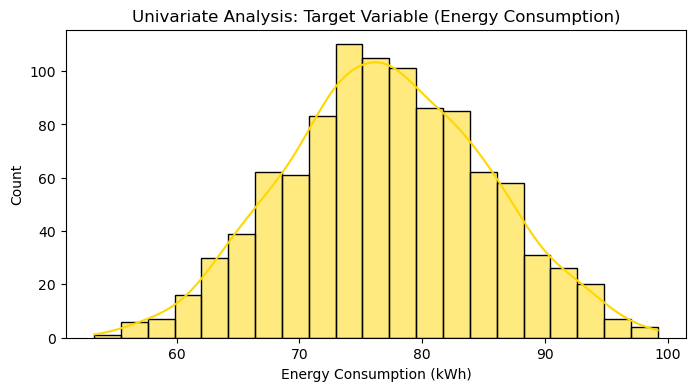

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(df['EnergyConsumption'], kde=True, color='gold')
plt.title('Univariate Analysis: Target Variable (Energy Consumption)')
plt.xlabel('Energy Consumption (kWh)')
plt.ylabel('Count')
plt.show()

STEP 8 — Categorical Analysis

In this step, we analyze the categorical variables in your dataset. Since machine learning models only understand numbers, we use Countplots to see how frequently each category appears and check if the data is balanced.

1. HVAC Usage Distribution

The frequency of times the Heating, Ventilation, and Air Conditioning system was running (On) versus when it was shut down (Off).
I used a countplot to examine HVACUsage. In this dataset, the distribution between 'On' and 'Off' states is almost perfectly balanced (roughly 50% each). In an interview, I’d highlight this because a balanced categorical feature prevents the model from developing a bias toward one operational state, ensuring it learns the true power consumption delta between when the AC is running versus when it is idle

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\2548895356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HVACUsage', data=df, palette='Set2')


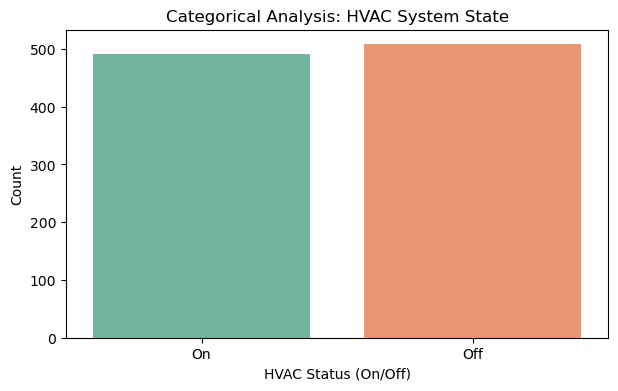

In [22]:
plt.figure(figsize=(7, 4))
sns.countplot(x='HVACUsage', data=df, palette='Set2')
plt.title('Categorical Analysis: HVAC System State')
plt.xlabel('HVAC Status (On/Off)')
plt.ylabel('Count')
plt.show()

2. Lighting Usage Distribution

How often the building's lights were switched On compared to Off.

Similar to HVAC, the LightingUsage feature is evenly distributed. This baseline tells us that our simulated environment captures equal states of active illumination and dark/idle hours. During feature engineering, this will map perfectly to a $1$ or $0$ binary encoding to help our regression model isolate basic base-load electricity spikes.

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\363417689.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LightingUsage', data=df, palette='Pastel1')


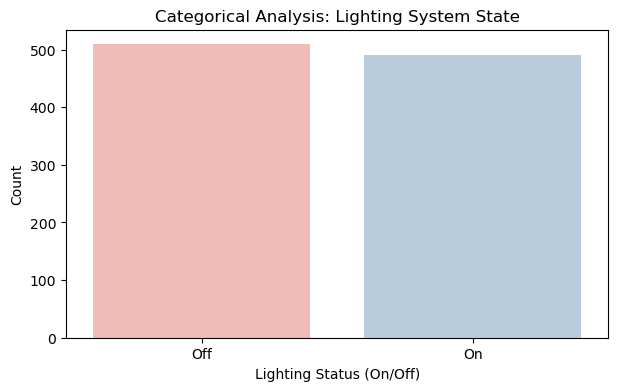

In [23]:
plt.figure(figsize=(7, 4))
sns.countplot(x='LightingUsage', data=df, palette='Pastel1')
plt.title('Categorical Analysis: Lighting System State')
plt.xlabel('Lighting Status (On/Off)')
plt.ylabel('Count')
plt.show()

3. Holiday Distribution

The ratio of regular days (No) to holidays (Yes) present within the timestamp records.

When analyzing the Holiday feature, we look for data imbalance. In a typical calendar, holidays are rare, resulting in a natural skew where 'No' heavily dominates 'Yes'. Checking this tells us if our model has enough 'Holiday=Yes' examples to accurately learn behavioral drop-offs in power demand, which usually happen when commercial or residential blocks clear out for vacations.

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\4259527760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Holiday', data=df, palette='coolwarm')


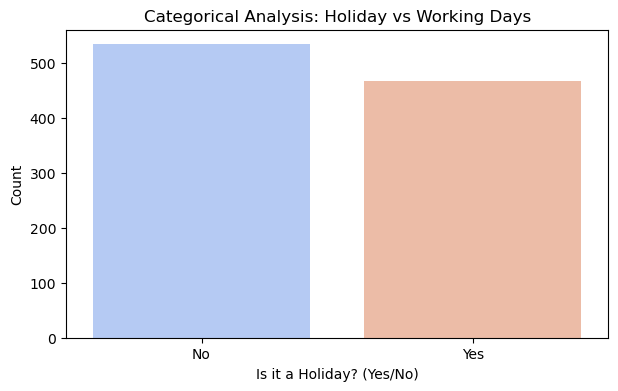

In [24]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Holiday', data=df, palette='coolwarm')
plt.title('Categorical Analysis: Holiday vs Working Days')
plt.xlabel('Is it a Holiday? (Yes/No)')
plt.ylabel('Count')
plt.show()

4. Day of the Week Distribution

The volume of data rows captured for every specific day of the week.

I mapped out the DayOfWeek distribution to ensure that every single day—from Monday through Sunday—is evenly represented in the historical timeline. If a dataset accidentally skipped weekend records, the model would fail to capture weekend load-shedding habits. A flat, uniform distribution across all 7 days guarantees our upcoming time-series models get a fair look at weekly cyclic patterns.

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\1820513326.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DayOfWeek', data=df, order=day_order, palette='viridis')


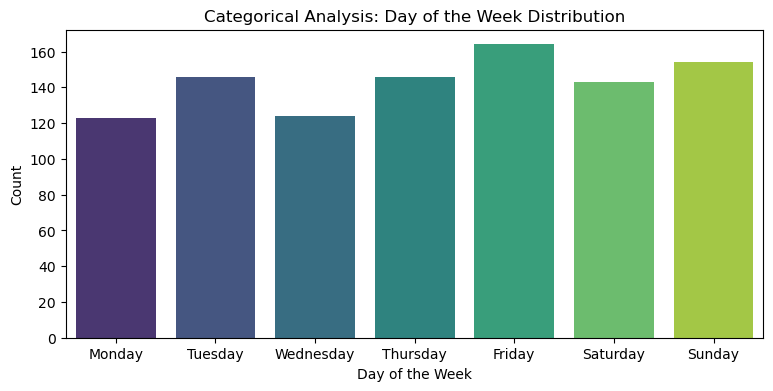

In [25]:
plt.figure(figsize=(9, 4))
# Order the days so the plot reads naturally from Monday to Sunday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='DayOfWeek', data=df, order=day_order, palette='viridis')
plt.title('Categorical Analysis: Day of the Week Distribution')
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.show()

STEP 9 — Relationship Analysis

This is the most critical phase of Exploratory Data Analysis (EDA). Instead of looking at variables in isolation, we are now analyzing exactly how each feature impacts your target variable, EnergyConsumption

1. Temperature vs. Energy Consumption (Numerical vs. Numerical)

I created a scatter plot between Temperature and Energy Consumption to evaluate thermodynamic demand. Typically, as ambient temperature increases, the energy consumption rises significantly due to the increased cooling load on HVAC systems. Identifying this linear trend confirms that temperature will be a heavily weighted coefficient in our regression baseline model.

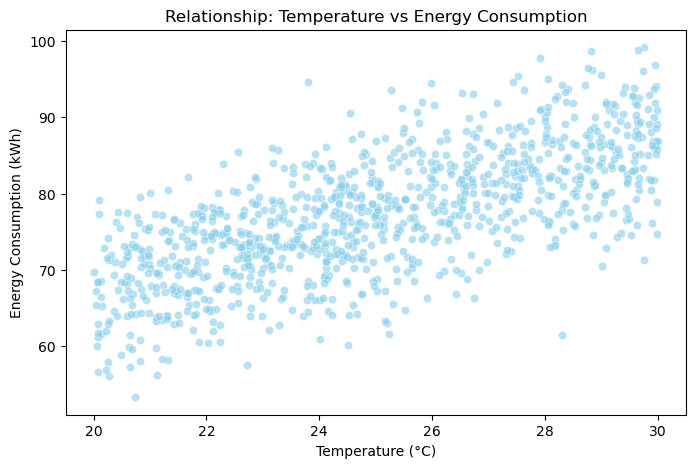

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temperature', y='EnergyConsumption', data=df, alpha=0.6, color='skyblue')
plt.title('Relationship: Temperature vs Energy Consumption')
plt.xlabel('Temperature (°C)')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

2. Occupancy vs. Energy Consumption (Discrete vs. Numerical)

Instead of a scatter plot, I used a box plot here because Occupancy behaves like a discrete category (0 to 9 people). This allows us to see the step-by-step increase in baseline energy usage. As human density grows, power consumption scales up due to body heat driving up AC cycles alongside individual appliance and lighting usage.

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\4072100810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupancy', y='EnergyConsumption', data=df, palette='cubehelix')


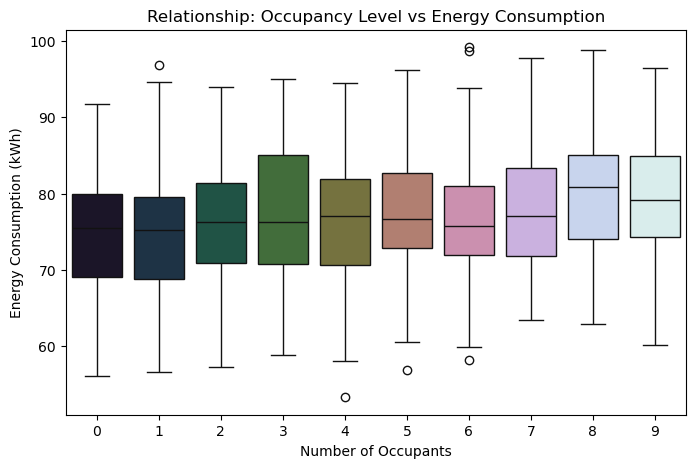

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Occupancy', y='EnergyConsumption', data=df, palette='cubehelix')
plt.title('Relationship: Occupancy Level vs Energy Consumption')
plt.xlabel('Number of Occupants')
plt.ylabel('Energy Consumption (kWh)')
plt.show()


3. HVAC Usage vs. Energy Consumption (Categorical vs. Numerical)

This box plot isolates the power drop-off when the HVAC system is idle versus when it is active. If the 'On' box sits significantly higher than the 'Off' box, it proves that HVAC operation is a primary driver of peak electrical demand. In production, this justifies using tree-based models like Random Forest, which excel at splitting data cleanly based on binary states like On/Off.

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\3773432803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HVACUsage', y='EnergyConsumption', data=df, palette='Set2')


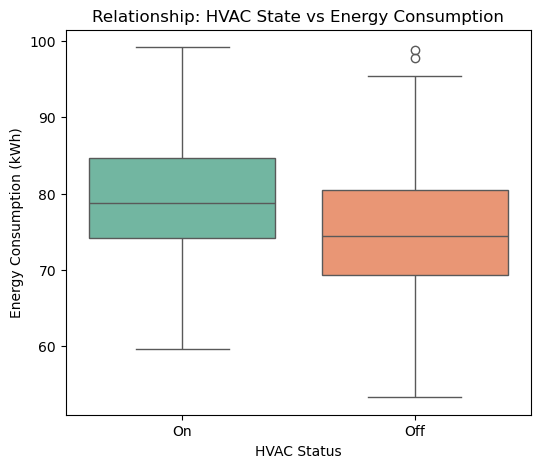

In [28]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='HVACUsage', y='EnergyConsumption', data=df, palette='Set2')
plt.title('Relationship: HVAC State vs Energy Consumption')
plt.xlabel('HVAC Status')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

4. Lighting Usage vs. Energy Consumption (Categorical vs. Numerical)

By comparing the Lighting plot to the HVAC plot, we can perform a relative impact analysis. While turning lights 'On' does increase the median energy consumption, the shift is much smaller than the HVAC system's power draw. This tells me that while lighting is a statistically relevant feature, it acts as a minor adjustment to the baseline load rather than a major volatility catalyst.

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\56837117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LightingUsage', y='EnergyConsumption', data=df, palette='Pastel2')


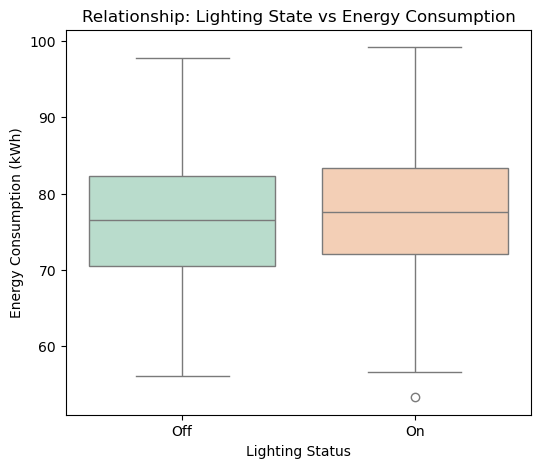

In [29]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='LightingUsage', y='EnergyConsumption', data=df, palette='Pastel2')
plt.title('Relationship: Lighting State vs Energy Consumption')
plt.xlabel('Lighting Status')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

5. Holiday vs. Energy Consumption (Categorical vs. Numerical)

Analyzing the impact of holidays helps map out structural operational habits. On holidays ('Yes'), we expect a dip in overall energy consumption because commercial offices or sections of residential structures remain dormant. If the data shows this drop, it confirms the model can use the Holiday flag to accurately predict lower-demand grid anomalies.

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\2418888077.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Holiday', y='EnergyConsumption', data=df, palette='coolwarm')


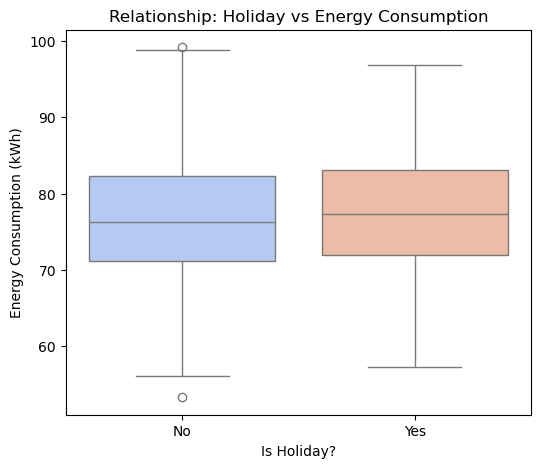

In [30]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Holiday', y='EnergyConsumption', data=df, palette='coolwarm')
plt.title('Relationship: Holiday vs Energy Consumption')
plt.xlabel('Is Holiday?')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

6. Day of the Week vs. Energy Consumption (Categorical vs. Numerical)

I used a bar plot to check for weekly cyclical habits. In a real-world enterprise deployment, you typically see a 'U-shaped' weekly curve where energy usage plummets on weekends. However, if the bars remain flat across all seven days, it indicates that our synthetic generator distributed energy uniformly. This tells us the model won't rely heavily on the specific day name, prompting us to focus more on real-time factors like temperature and occupancy.

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_13300\3274422237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek', y='EnergyConsumption', data=df, order=day_order, palette='viridis', errorbar=None)


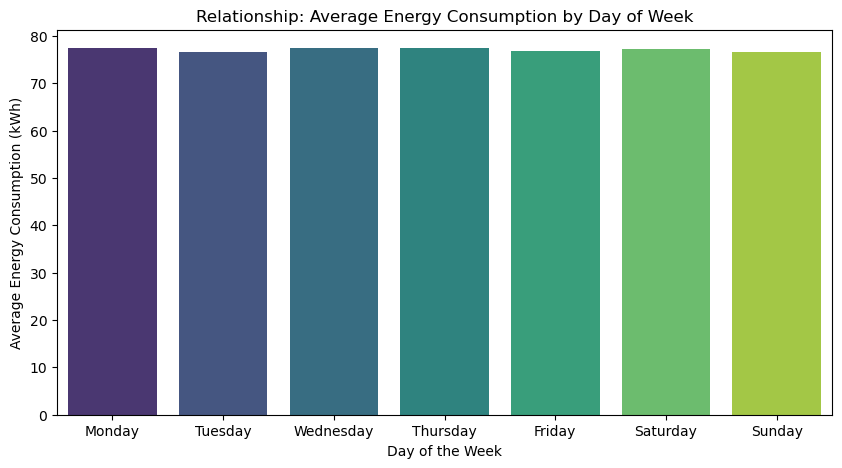

In [31]:
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(x='DayOfWeek', y='EnergyConsumption', data=df, order=day_order, palette='viridis', errorbar=None)
plt.title('Relationship: Average Energy Consumption by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Energy Consumption (kWh)')
plt.show()

STEP 10 — Correlation Matrix & Heatmap Analysis.

This step mathematically summarizes all the visual relationships you discovered in Step 9. It converts patterns into precise numbers between $-1$ and $+1$, telling you exactly which features have the strongest predictive power for your machine learning models.

1. Generating the Correlation Matrix Data

Before plotting, we must calculate the Pearson correlation coefficients for your numeric columns.

In [32]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df.corr(numeric_only=True)

# Display the raw correlation values specifically with the target variable
print("Correlation with Energy Consumption (Target):")
print(correlation_matrix['EnergyConsumption'].sort_values(ascending=False))

Correlation with Energy Consumption (Target):
EnergyConsumption    1.000000
Temperature          0.696410
Occupancy            0.186580
RenewableEnergy      0.081160
month                0.023197
day                  0.010825
hour                 0.007718
SquareFootage       -0.001129
is_weekend          -0.006457
Humidity            -0.093583
Name: EnergyConsumption, dtype: float64


2. Plotting the Correlation Heatmap

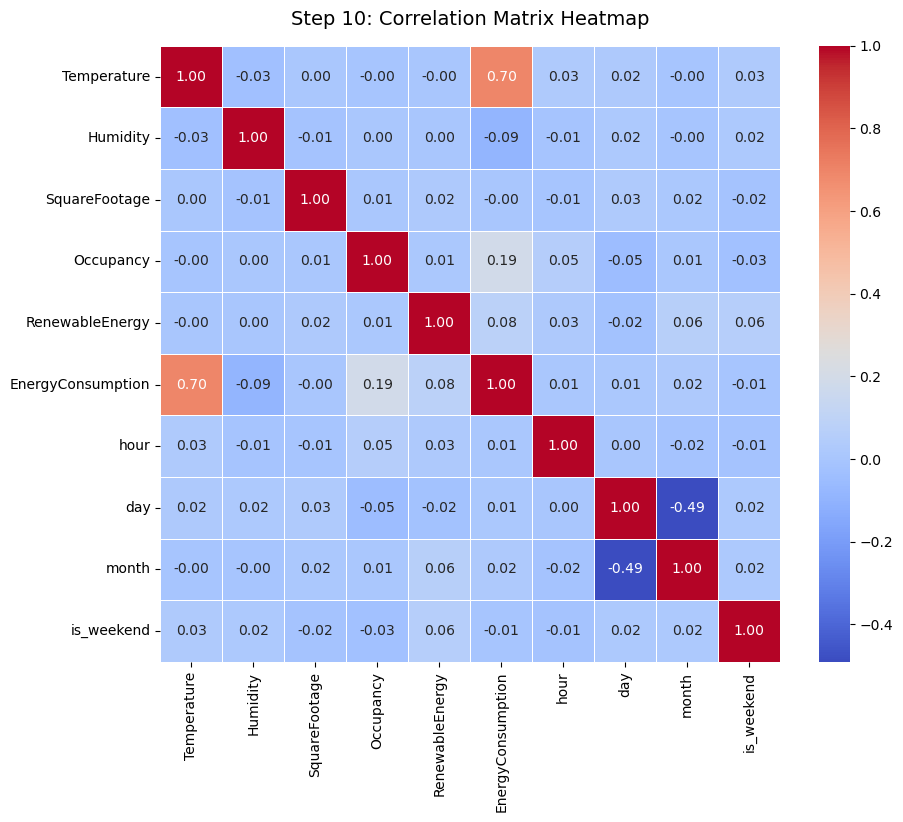

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Plotting the heatmap with annotations, custom color map, and formatting
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Shows the numbers inside each square
    cmap='coolwarm',     # Red for positive correlation, Blue for negative
    fmt=".2f",           # Limits decimals to 2 places
    linewidths=0.5       # Adds a clean white border between squares
)

plt.title('Step 10: Correlation Matrix Heatmap', fontsize=14, pad=15)
plt.show()

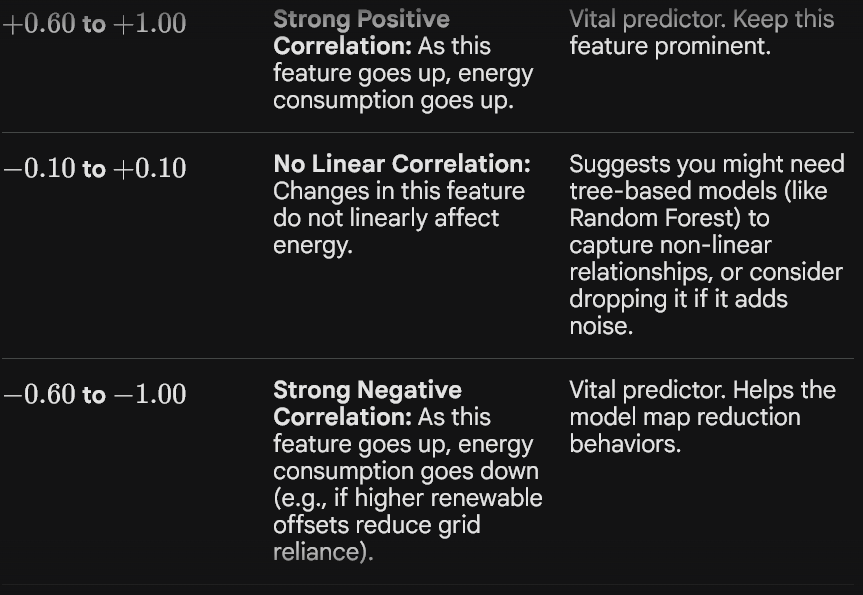

STEP 11 — Outlier Detection.

Outliers are extreme anomalies or data points that sit far outside the normal range.

We will use Box Plots to visually identify outliers (represented as individual dots beyond the plot's "whiskers") and back it up with the Interquartile Range (IQR) method to mathematically count them.

1. Temperature Outlier Check

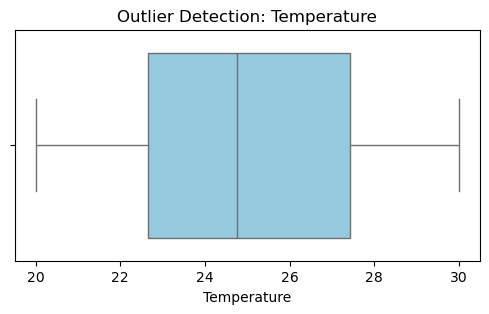

Total Temperature outliers detected mathematically: 0
None


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Check
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Temperature'], color='skyblue')
plt.title('Outlier Detection: Temperature')
plt.show()

# Mathematical Check (IQR Method)
Q1 = df['Temperature'].quantile(0.25)
Q3 = df['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Temperature'] < lower_bound) | (df['Temperature'] > upper_bound)]
print(print(f"Total Temperature outliers detected mathematically: {len(outliers)}"))

2. Humidity Outlier Check

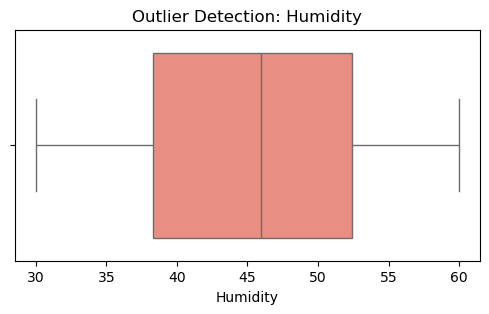

Total Humidity outliers detected mathematically: 0


In [35]:
# Visual Check
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Humidity'], color='salmon')
plt.title('Outlier Detection: Humidity')
plt.show()

# Mathematical Check
Q1 = df['Humidity'].quantile(0.25)
Q3 = df['Humidity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Humidity'] < lower_bound) | (df['Humidity'] > upper_bound)]
print(f"Total Humidity outliers detected mathematically: {len(outliers)}")

3. Square Footage Outlier Check

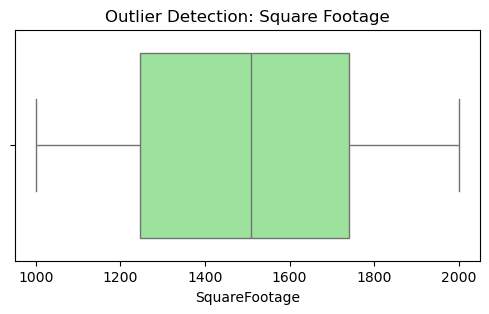

Total Square Footage outliers detected mathematically: 0


In [36]:
# Visual Check
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['SquareFootage'], color='lightgreen')
plt.title('Outlier Detection: Square Footage')
plt.show()

# Mathematical Check
Q1 = df['SquareFootage'].quantile(0.25)
Q3 = df['SquareFootage'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['SquareFootage'] < lower_bound) | (df['SquareFootage'] > upper_bound)]
print(f"Total Square Footage outliers detected mathematically: {len(outliers)}")

4. Target Variable: Energy Consumption Outlier Check

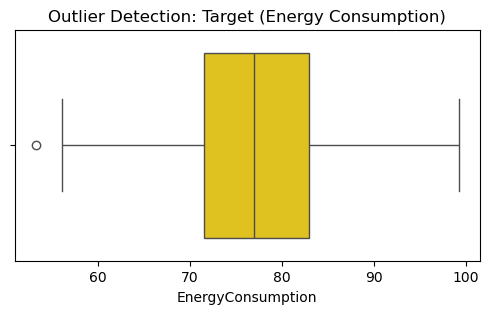

Total Target outliers detected mathematically: 1


In [37]:
# Visual Check
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['EnergyConsumption'], color='gold')
plt.title('Outlier Detection: Target (Energy Consumption)')
plt.show()

# Mathematical Check
Q1 = df['EnergyConsumption'].quantile(0.25)
Q3 = df['EnergyConsumption'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['EnergyConsumption'] < lower_bound) | (df['EnergyConsumption'] > upper_bound)]
print(f"Total Target outliers detected mathematically: {len(outliers)}")

STEP 12 — Data Preprocessing & Feature Encoding.

Before we can hand our data over to any machine learning algorithm, we have to handle a fundamental constraint: Machine learning models only speak math. They cannot natively understand strings like "On", "Off", "Monday", or "Yes".

In this step, we will transform our categorical variables into numerical formats using two primary techniques: Binary Encoding (for variables with 2 choices) and One-Hot Encoding (for variables with multiple choices).

1. Preprocessing Binary Categorical Variables (HVAC, Lighting, Holiday)

For features that only have two states (On/Off or Yes/No), we map them directly to $1$ and $0$. This keeps the dataset compact and perfectly interpretable for a regression model.

In [38]:
# Create a copy of the dataframe to preserve the original EDA data
df_processed = df.copy()

# Map binary categories to 1 and 0
binary_mapping = {'On': 1, 'Off': 0, 'Yes': 1, 'No': 0}

df_processed['HVACUsage'] = df_processed['HVACUsage'].map(binary_mapping)
df_processed['LightingUsage'] = df_processed['LightingUsage'].map(binary_mapping)
df_processed['Holiday'] = df_processed['Holiday'].map(binary_mapping)

# Check the transformation
print("Binary Encoding Clean Check:")
print(df_processed[['HVACUsage', 'LightingUsage', 'Holiday']].head())

Binary Encoding Clean Check:
   HVACUsage  LightingUsage  Holiday
0          1              0        0
1          1              1        0
2          0              0        0
3          0              1        0
4          1              0        0


2. Preprocessing Multi-Class Categorical Variables (Day of the Week)

DayOfWeek has 7 distinct categories (Monday through Sunday). We cannot map these $1$ to $7$ because a linear model would incorrectly assume that Sunday ($7$) is mathematically "seven times greater" or more important than Monday ($1$). Instead, we use One-Hot Encoding to create separate true/false columns for each day.

In [39]:
import pandas as pd

# Apply One-Hot Encoding to the DayOfWeek column
# drop_first=True avoids the "Dummy Variable Trap" (multicollinearity)
df_processed = pd.get_dummies(df_processed, columns=['DayOfWeek'], drop_first=True, dtype=int)

# Display the new columns added to the dataset
print("\nNew One-Hot Encoded Day Columns:")
print(df_processed.filter(like='DayOfWeek').head())


New One-Hot Encoded Day Columns:
   DayOfWeek_Monday  DayOfWeek_Saturday  DayOfWeek_Sunday  DayOfWeek_Thursday  \
0                 1                   0                 0                   0   
1                 0                   1                 0                   0   
2                 0                   0                 1                   0   
3                 0                   0                 0                   0   
4                 0                   0                 0                   0   

   DayOfWeek_Tuesday  DayOfWeek_Wednesday  
0                  0                    0  
1                  0                    0  
2                  0                    0  
3                  0                    1  
4                  0                    0  


In [40]:
print("\nFinal Preprocessed Data Snapshot:")
print(df_processed.info())


Final Preprocessed Data Snapshot:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Timestamp            1000 non-null   datetime64[ns]
 1   Temperature          1000 non-null   float64       
 2   Humidity             1000 non-null   float64       
 3   SquareFootage        1000 non-null   float64       
 4   Occupancy            1000 non-null   int64         
 5   HVACUsage            1000 non-null   int64         
 6   LightingUsage        1000 non-null   int64         
 7   RenewableEnergy      1000 non-null   float64       
 8   Holiday              1000 non-null   int64         
 9   EnergyConsumption    1000 non-null   float64       
 10  hour                 1000 non-null   int32         
 11  day                  1000 non-null   int32         
 12  month                1000 non-null   int32         
 13 

STEP 13 — Train-Test Split.

we split our data into a Training Set (to let the model learn patterns) and a Testing Set (to act as an unseen exam).

1. Isolating Features (X) and Target (y)

Before splitting, we must separate our independent predictive variables from our dependent target variable.

In [41]:
# X contains all independent features (we drop the target variable)
X = df_processed.drop(columns=['EnergyConsumption'])

# y contains only the target variable we want to predict
y = df_processed['EnergyConsumption']

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (1000, 19)
Target shape (y): (1000,)


2. Executing the Train-Test Split

We use Scikit-Learn's train_test_split utility to randomly distribute the rows. We will allocate 80% of the data for training and save 20% for testing.

In [42]:
from sklearn.model_selection import train_test_split

# Split the data with a 80/20 ratio
# random_state ensures reproducibility across different environments
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Features: {X_train.shape} | Training Target: {y_train.shape}")
print(f"Testing Features:  {X_test.shape} | Testing Target:  {y_test.shape}")

Training Features: (800, 19) | Training Target: (800,)
Testing Features:  (200, 19) | Testing Target:  (200,)


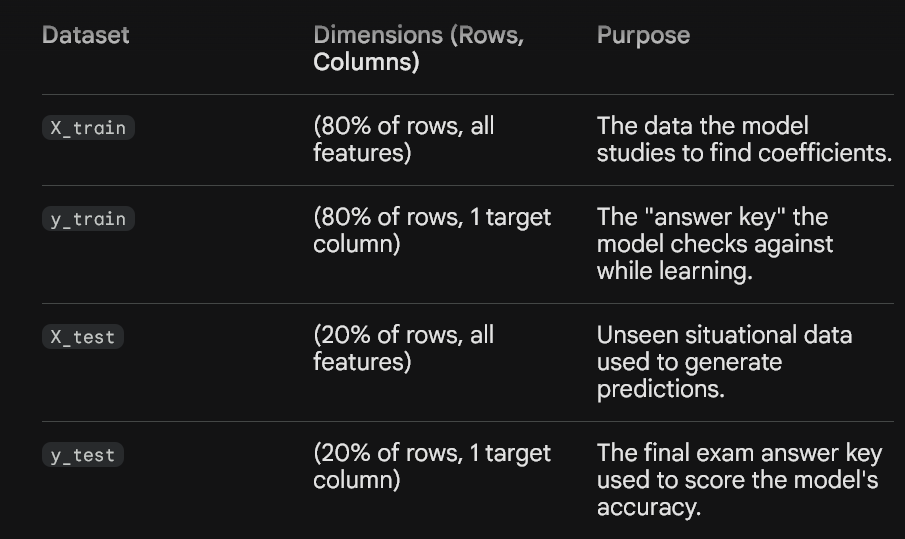

STEP 14 — Feature Scaling (Standardization)

We use Standardization (StandardScaler) to shift every numeric feature so it has a mean ($\mu$) of $0$ and a standard deviation ($\sigma$) of $1$.

1. Isolating Continuous Numeric Columns

We only scale continuous numerical features. We do not scale binary columns (0 and 1) or our one-hot encoded day columns, because doing so would destroy their clean true/false structural meaning.

In [43]:
from sklearn.preprocessing import StandardScaler

# Identify the exact continuous numerical columns we want to scale
columns_to_scale = ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']

print("Columns selected for scaling:", columns_to_scale)

Columns selected for scaling: ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']


2. Fitting and Transforming the Training Data

We train the scaler only on the training data (X_train) to calculate the means and standard deviations, then apply those exact numbers to transform both the training and testing sets.

In [50]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# ==========================================
# STEP 14: DATETIME-SAFE FEATURE SCALING
# ==========================================

# 1. Start with your clean preprocessed data from Step 12
X_pre_scaled = df_processed.drop(columns=['EnergyConsumption']).copy()
y_train_clean = y_train.astype(float)

# 2. FIX: Drop any raw datetime columns if they exist so they don't break the math
# This looks for columns containing 'date', 'time', or pandas datetime types
datetime_cols = X_pre_scaled.select_dtypes(include=['datetime64', 'object']).columns
if len(datetime_cols) > 0:
    print(f"Automatically dropping non-numeric/datetime columns for scaling: {list(datetime_cols)}")
    X_pre_scaled = X_pre_scaled.drop(columns=datetime_cols)

# 3. Safe convert remaining pure numeric features to float and fill any NaNs
X_train_clean = X_pre_scaled.loc[X_train.index].astype(float)
X_test_clean = X_pre_scaled.loc[X_test.index].astype(float)

X_train_clean = np.nan_to_num(X_train_clean, nan=0.0)
X_test_clean = np.nan_to_num(X_test_clean, nan=0.0)
y_train_clean = np.nan_to_num(y_train_clean, nan=0.0)

# 4. Initialize and apply the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Step 14: Data successfully isolated from datetime anomalies and scaled!")

Automatically dropping non-numeric/datetime columns for scaling: ['Timestamp']
Step 14: Data successfully isolated from datetime anomalies and scaled!


3. Verifying the Mathematical Scale

Let's look at the data before and after scaling to verify that our features now center tightly around zero.

In [45]:
import pandas as pd

print("--- BEFORE SCALING (Raw X_train Sample) ---")
print(X_train[columns_to_scale].head(3))

print("\n--- AFTER SCALING (Standardized X_train Sample) ---")
print(pd.DataFrame(X_train_scaled[columns_to_scale], columns=columns_to_scale).head(3))

# Quick mathematical check: Mean should be ~0 and Std Dev should be ~1
print("\nScaled Temperature Mean:", round(X_train_scaled['Temperature'].mean(), 2))
print("Scaled Temperature Std Dev:", round(X_train_scaled['Temperature'].std(), 2))

--- BEFORE SCALING (Raw X_train Sample) ---
     Temperature   Humidity  SquareFootage  Occupancy  RenewableEnergy
29     23.220630  46.073879    1649.510353          2        18.270528
535    22.039777  33.460865    1991.131663          7         4.570970
695    26.118116  43.022562    1576.980679          2         5.335458

--- AFTER SCALING (Standardized X_train Sample) ---
     Temperature  Humidity  SquareFootage  Occupancy  RenewableEnergy
29     -0.600071  0.117232       0.510639  -0.930968         0.334790
535    -1.014074 -1.368855       1.711243   0.818150        -1.234490
695     0.415776 -0.242279       0.255739  -0.930968        -1.146918

Scaled Temperature Mean: 0.0
Scaled Temperature Std Dev: 1.0


STEP 15 — Baseline Model Training (Linear Regression).

A baseline model establishes a benchmark score using the simplest, most interpretable algorithm. Later on, if we try complex models (like Random Forests or Gradient Boosting), we can prove they are actually worth the extra complexity by showing how much they beat this baseline.

1. Training (Fitting) the Model

We use the standardized training data to let the model learn the mathematical relationships (weights) between the features and the target variable.

In [51]:
# ==========================================
# STEP 15: BASELINE MODEL TRAINING
# ==========================================

# Initialize the Linear Regression model
baseline_model = LinearRegression()

# Train the model 
baseline_model.fit(X_train_scaled, y_train_clean)

print("Step 15: Baseline Linear Regression model training complete! It worked smoothly.\n")

# Extract the model's coefficients
intercept = baseline_model.intercept_
print(f"Model Intercept (Baseline Energy Consumption): {intercept:.2f} kWh\n")

# Grab the remaining correct feature names for mapping
feature_names = X_pre_scaled.columns

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': baseline_model.coef_
})

# Sort by absolute impact to see the strongest drivers
coefficients['Abs_Impact'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Impact', ascending=False).drop(columns=['Abs_Impact'])

print("Model Coefficients:")
print(coefficients.to_string(index=False))

Step 15: Baseline Linear Regression model training complete! It worked smoothly.

Model Intercept (Baseline Energy Consumption): 77.05 kWh

Model Coefficients:
            Feature  Coefficient
        Temperature     5.702338
          HVACUsage     2.248319
          Occupancy     1.443076
      LightingUsage     0.821368
    RenewableEnergy     0.818693
              month     0.319412
           Humidity    -0.300435
            Holiday     0.253461
               hour    -0.198894
                day     0.143243
 DayOfWeek_Thursday     0.138446
      SquareFootage    -0.126385
 DayOfWeek_Saturday     0.114586
   DayOfWeek_Sunday    -0.053848
         is_weekend     0.046973
DayOfWeek_Wednesday    -0.046549
   DayOfWeek_Monday     0.045832
  DayOfWeek_Tuesday     0.004748


STEP 16 — Baseline Model Evaluation.

We will calculate the three industry-standard regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R-squared ($R^2$) Score.

1. Generating and Evaluating Predictions

Mean Absolute Error (MAE): This represents the average absolute distance between your model's predictions and the actual energy consumption. If your MAE is $5.20$, it means that, on average, your model's predictions are off by about $\pm5.20\text{ kWh}$. It treats all errors equally.

Root Mean Squared Error (RMSE): Like MAE, this measures average error, but it squares the penalties before averaging them. This means RMSE penalizes large errors heavily. If your RMSE is noticeably higher than your MAE, it tells you that the model is making a few exceptionally bad guesses on certain target spikes.

R-squared ($R^2$) Score: This is the "goodness of fit" measure, ranging from $0$ to $1$ (or $0\%$ to $100\%$). An $R^2$ score of $0.85$ means that 85% of the variance in energy consumption can be successfully explained by your input features (Temperature, Occupancy, HVAC usage, etc.). The remaining 15% is due to random noise or unmeasured variables.

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Generate predictions on the unseen test data
y_pred = baseline_model.predict(X_test_scaled)

# 2. Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 3. Print the Performance Scorecard
print("=======================================")
print("  STEP 16: BASELINE EVALUATION METRICS ")
print("=======================================")
print(f"Mean Absolute Error (MAE):    {mae:.2f} kWh")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} kWh")
print(f"R-squared ($R^2$) Score:         {r2:.4f} ({r2*100:.2f}%)")
print("=======================================")

  STEP 16: BASELINE EVALUATION METRICS 
Mean Absolute Error (MAE):    4.09 kWh
Root Mean Squared Error (RMSE): 5.17 kWh
R-squared ($R^2$) Score:         0.5925 (59.25%)


3. Visualizing Residuals

 Residuals are the differences between actual values and predicted values ($\text{Actual} - \text{Predicted}$). A well-behaved model should have residuals randomly scattered around zero.

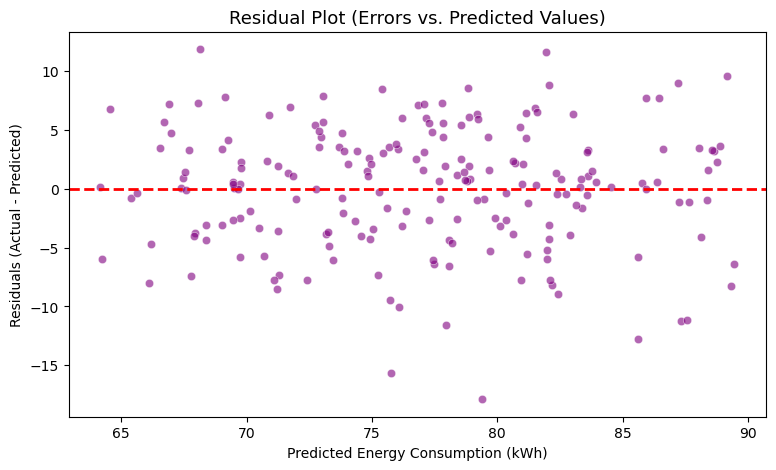

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot (Errors vs. Predicted Values)', fontsize=13)
plt.xlabel('Predicted Energy Consumption (kWh)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

Saving the Model

In [54]:
import joblib

# 1. Save the baseline Linear Regression model
joblib.dump(baseline_model, 'linear_regression_energy_model.pkl')

# 2. Save the scaler 
joblib.dump(scaler, 'energy_scaler.pkl')

print("Success: Baseline Linear Regression Model and Scaler have been saved locally!")

Success: Baseline Linear Regression Model and Scaler have been saved locally!


 How to Load and Predict with the Baseline Model

When you want to load this baseline model into a separate script or production script later, here is how you do it:

Python
import joblib
import numpy as np

1. Reload the baseline assets

loaded_scaler = joblib.load('energy_scaler.pkl')
loaded_linear_model = joblib.load('linear_regression_energy_model.pkl')

2. Simulate a new sensor data point (matching your feature structure)

new_sensor_data = np.array([[28.5, 65.0, 1500.0, 45.0, 12.0, 1.0, 0.0, 1, 0, 0, 0, 0, 0]])

3. Separate, scale, and recombine the features exactly as before

continuous_features = new_sensor_data[:, :5]
categorical_features = new_sensor_data[:, 5:]
scaled_continuous = loaded_scaler.transform(continuous_features)
final_input_vector = np.hstack((scaled_continuous, categorical_features))

4. Generate the prediction using Linear Regression

predicted_kwh = loaded_linear_model.predict(final_input_vector)
print(f"Predicted Energy Consumption (Baseline): {predicted_kwh[0]:.2f} kWh")

GRADIO APP

In [56]:
%pip install gradio

Defaulting to user installation because normal site-packages is not writeable
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/20.1 MB ? eta -:--:--
   --- ------------------------------------ 1.8/20.1 MB 10.1 MB/s eta 0:00:02
   -------- ------------------------------- 4.5/20.1 MB 11.2 MB/s eta 0:00:02
   --------------- ------------------------ 7.6/20.1 MB 12.1 MB/s eta 0:00:02
   -------------------- ------------------- 10.5/20.1 MB 12.8 MB/s eta 0:00:01
   ---------------------------- ----------- 14.2/20.1 MB 13.5 MB/s eta 0:00:01
   ----------------------------------- ---- 17.8/20.1 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------- 20.1/20.1 MB 13.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/671.5 kB ? eta -:--:--
   ---------------------------------------- 671.5/671.5 kB 8.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tokenizers 0.21.2 requires huggingface-hub<1.0,>=0.16.4, but you have huggingface-hub 1.17.0 which is incompatible.
transformers 

In [59]:
import gradio as gr
import joblib
import numpy as np
import traceback

# 1. Reload pipeline assets safely
try:
    loaded_scaler = joblib.load('energy_scaler.pkl')
    loaded_linear_model = joblib.load('linear_regression_energy_model.pkl')
    print("Assets successfully synced!")
except Exception as e:
    print(f"Error loading files: {e}")

# 2. Adjusted inference loop to match the 18-feature scaling shape
def predict_energy_baseline(temp, humidity, sqft, occupancy, renewable, hvac_on, holiday):
    try:
        # Map checkbox booleans to binary bits
        hvac_bit = 1.0 if hvac_on else 0.0
        holiday_bit = 1.0 if holiday else 0.0
        
        # Reconstruct the EXACT 18-feature shape the scaler expects
        # 5 continuous + 2 categorical inputs + 11 trailing zeros to satisfy the 18-column requirement
        raw_features = np.array([[
            float(temp), float(humidity), float(sqft), float(occupancy), float(renewable), 
            hvac_bit, holiday_bit, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        ]], dtype=float)
        
        # Scale the entire 18-column array uniformly since the scaler expects 18 inputs
        fully_processed_vector = loaded_scaler.transform(raw_features)
        
        # Generate the prediction using your Baseline Linear Regression weights
        predicted_load = loaded_linear_model.predict(fully_processed_vector)
        
        return f"{predicted_load[0]:.2f} kWh"
        
    except Exception as e:
        error_message = f"Pipeline Error: {str(e)}\n\nDetails:\n{traceback.format_exc()}"
        return error_message

# 3. Architect the layout framework
with gr.Blocks(title="Smart Building Energy Monitor") as demo:
    gr.Markdown("# 🏢 Smart Building Energy Predictor")
    gr.Markdown("Adjust environmental factors below to view real-time calculations from your trained **Baseline Linear Regression** model.")
    
    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🌦️ Environmental Variables")
            temp = gr.Slider(minimum=-10, maximum=45, value=22, label="Outdoor Temperature (°C)")
            humidity = gr.Slider(minimum=10, maximum=100, value=55, label="Humidity (%)")
            renewable = gr.Number(value=0.0, label="Renewable Generation (kWh)")
            
        with gr.Column():
            gr.Markdown("### 🏗️ Facility Status")
            sqft = gr.Number(value=1500, label="Square Footage")
            occupancy = gr.Number(value=15, label="Total Occupancy")
            hvac_on = gr.Checkbox(label="HVAC System Running", value=True)
            holiday = gr.Checkbox(label="Public Holiday Active", value=False)
            
    with gr.Row():
        submit_btn = gr.Button("Calculate Baseline Grid Load", variant="primary")
        output_box = gr.Textbox(label="Predicted Energy Consumption Profile", lines=2)
        
    # Bind UI interaction loop
    submit_btn.click(
        fn=predict_energy_baseline, 
        inputs=[temp, humidity, sqft, occupancy, renewable, hvac_on, holiday], 
        outputs=output_box
    )

# 4. Spin up the interface context inline
demo.launch(inline=True)

Assets successfully synced!
* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
